In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/home/gq11/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
df = pd.read_parquet("/home/gq11/Documents/Code/Jupiter Notebook/df_clean.parquet")

How has Steam evolved over time?

In [38]:
df2 = df.copy()

In [ ]:
df2['release_year'] = df2['release_date'].dt.year
df2 = df2[(df2['release_year'] > 2003) & (df2['release_year'] < 2026)].sort_values(by='release_year')

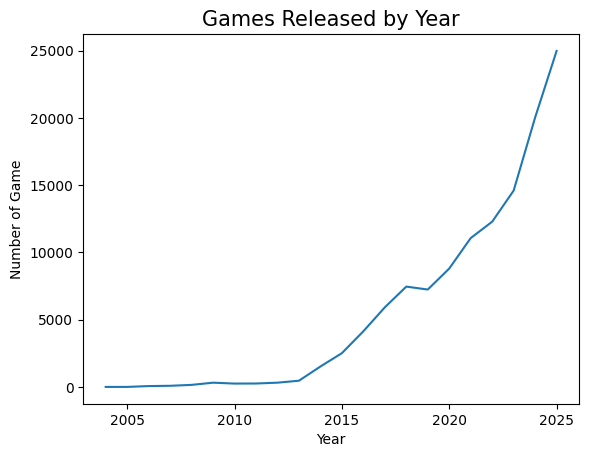

In [41]:
df2.groupby('release_year').size().plot()
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.title('Games Released by Year', fontsize=15)
plt.show()

Which game tags dominate the Steam marketplace?

In [113]:
df2 = df.copy()

In [114]:
df2['release_year'] = df2['release_date'].dt.year
df2 = df2[(df2['release_year'] > 2003) & (df2['release_year'] < 2026)].sort_values(by='release_year')
df2 = df2[['appID', 'release_year', 'genres']].explode('genres')

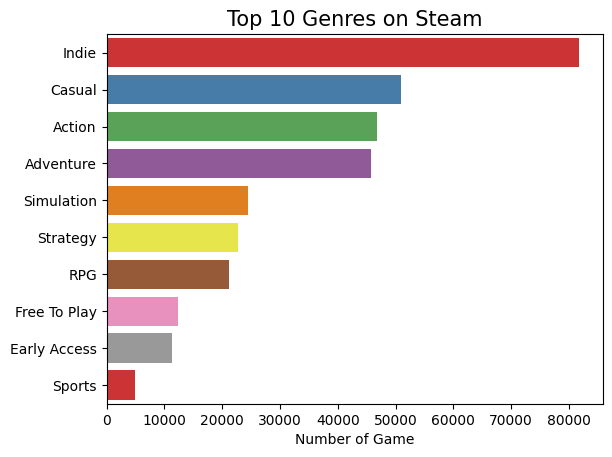

In [88]:
top10 = df2['genres'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="Set1")
plt.xlabel('Number of Game')
plt.ylabel('')
plt.title('Top 10 Genres on Steam', fontsize=15)
plt.show()

How have popular game tags changed over time?

In [115]:
df2.sample(5)

,appID,release_year,genres
13441,2140960,2022,Casual
71750,2640630,2023,Indie
25983,2732980,2024,Casual
20646,3428620,2025,Indie
24488,1480570,2020,Indie


In [116]:
top10index = df2['genres'].value_counts().head(10).index

In [117]:
df2 = df2.pivot_table(values='genres', index='release_year', columns='genres', aggfunc='size')[top10index]
df2

genres,Indie,Casual,Action,Adventure,Simulation,Strategy,RPG,Free To Play,Early Access,Sports
release_year,,,,,,,,,,
2004,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,3.0,NaN,2.0,NaN,NaN,2.0,4.0,NaN,NaN,NaN
2006,11.0,20.0,19.0,NaN,1.0,28.0,5.0,NaN,NaN,NaN
2007,7.0,12.0,49.0,9.0,2.0,25.0,9.0,2.0,NaN,NaN
2008,26.0,42.0,58.0,26.0,23.0,37.0,15.0,2.0,NaN,3.0
2009,63.0,67.0,110.0,75.0,53.0,69.0,44.0,3.0,NaN,8.0
2010,68.0,71.0,95.0,52.0,27.0,65.0,35.0,4.0,NaN,3.0
2011,106.0,48.0,118.0,64.0,27.0,83.0,40.0,13.0,NaN,5.0
2012,167.0,55.0,168.0,108.0,37.0,77.0,62.0,21.0,NaN,6.0


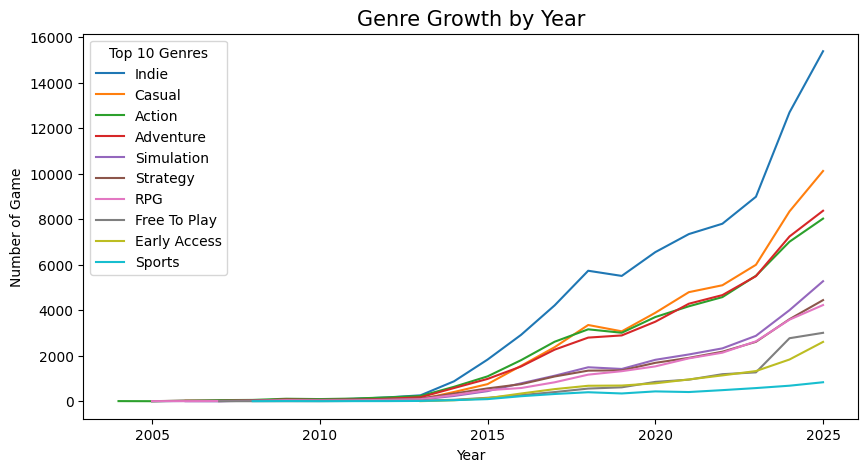

In [139]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df2, palette="tab10", dashes=False)
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.legend(title="Top 10 Genres")
plt.title('Genre Growth by Year', fontsize=15)
plt.show()